### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [2]:
data = pd.read_csv('data/coupons.csv')

In [8]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [9]:
#data.info()
data.isnull().sum()

destination             0
passanger               0
weather                 0
temperature             0
time                    0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
has_children            0
education               0
occupation              0
income                  0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
toCoupon_GEQ5min        0
toCoupon_GEQ15min       0
toCoupon_GEQ25min       0
direction_same          0
direction_opp           0
Y                       0
dtype: int64

3. Decide what to do about your missing data -- drop, replace, other...

In [3]:
data.count()

# Drop the car column if it exists (given it has only 108 values out of 12684 rows)
if 'car' in data.columns:
    data.drop('car', inplace=True, axis=1)

# Replace the null values in the Bar, CoffeeHouse, CarryAway, RestaurantLessThan20, Restaurant20To50 columns with the most frequent value
data['Bar'].fillna(data['Bar'].mode()[0], inplace=True)
data['CoffeeHouse'].fillna(data['CoffeeHouse'].mode()[0], inplace=True)
data['CarryAway'].fillna(data['CarryAway'].mode()[0], inplace=True)
data['RestaurantLessThan20'].fillna(data['RestaurantLessThan20'].mode()[0], inplace=True)
data['Restaurant20To50'].fillna(data['Restaurant20To50'].mode()[0], inplace=True)

# Convert age column to numeric (map age strings to representative numeric values)
age_mapping = {
    'below21': 20,
    '21': 21,
    '26': 26,
    '31': 31,
    '36': 36,
    '41': 41,
    '46': 46,
    '50plus': 50
}
data['age'] = data['age'].map(age_mapping).astype('Int64')

# Convert income column to numeric (map income ranges to their upper values)
income_mapping = {
    'Less than $12500': 12500,
    '$12500 - $24999': 24999,
    '$25000 - $37499': 37499,
    '$37500 - $49999': 49999,
    '$50000 - $62499': 62499,
    '$62500 - $74999': 74999,
    '$75000 - $87499': 87499,
    '$87500 - $99999': 99999,
    '$100000 or More': 100000
}
data['income'] = data['income'].map(income_mapping).astype('Int64')

data.isnull().sum()

C:\Users\lekka\AppData\Local\Temp\ipykernel_26156\2877483673.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Bar'].fillna(data['Bar'].mode()[0], inplace=True)
C:\Users\lekka\AppData\Local\Temp\ipykernel_26156\2877483673.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.



destination             0
passanger               0
weather                 0
temperature             0
time                    0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
has_children            0
education               0
occupation              0
income                  0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
toCoupon_GEQ5min        0
toCoupon_GEQ15min       0
toCoupon_GEQ25min       0
direction_same          0
direction_opp           0
Y                       0
dtype: int64

4. What proportion of the total observations chose to accept the coupon?



In [10]:
accepted_count = (data['Y'] == 1).sum()
declined_count = (data['Y'] == 0).sum()
portion_accepted = accepted_count / len(data)

print("accepted_count:", accepted_count)
print("declined_count:", declined_count)
print("portion_accepted:", portion_accepted)

accepted_count: 7210
declined_count: 5474
portion_accepted: 0.5684326710816777


5. Use a bar plot to visualize the `coupon` column.

C:\Users\lekka\AppData\Local\Temp\ipykernel_1600\722241484.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  bar_plot.set_xticklabels(['Declined', 'Accepted'])


[Text(0, 0, 'Declined'), Text(1, 0, 'Accepted')]

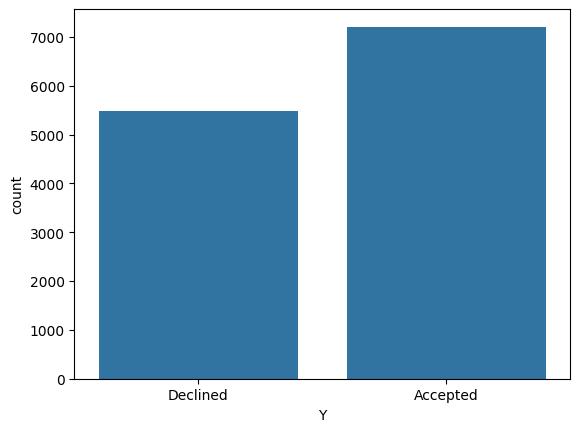

In [10]:
bar_plot = sns.countplot(x='Y', data=data)
bar_plot.set_xticklabels(['Declined', 'Accepted'])

6. Use a histogram to visualize the temperature column.

Text(0.5, 1.0, 'Distribution of Temperature')

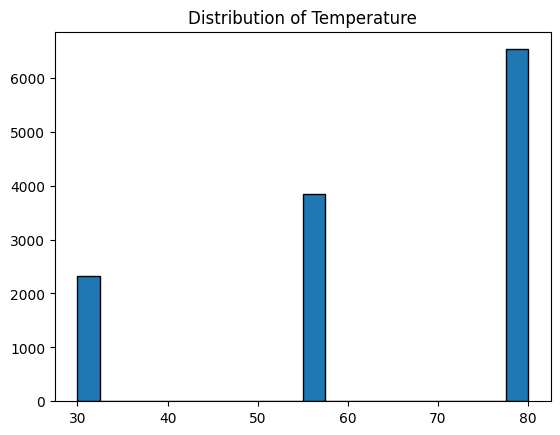

In [11]:

plt.hist(data['temperature'], bins=20, edgecolor='black')
plt.title('Distribution of Temperature')

Text(0.5, 1.0, 'Distribution of Time')

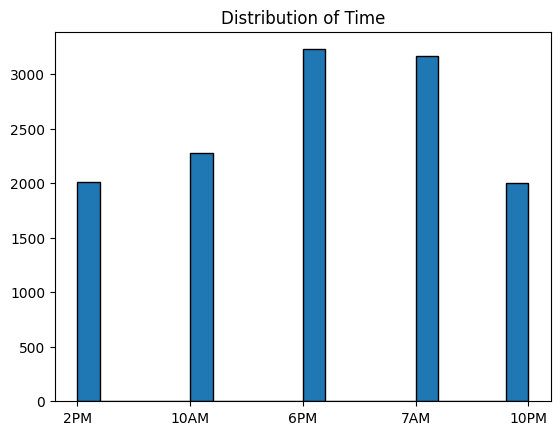

In [12]:
#graph the distribution of the time column
plt.hist(data['time'], bins=20, edgecolor='black')
plt.title('Distribution of Time')  


([<matplotlib.axis.XTick at 0x1127665f1d0>,
 [Text(0, 0, 'Opposite Direction'), Text(1, 0, 'Same Direction')])

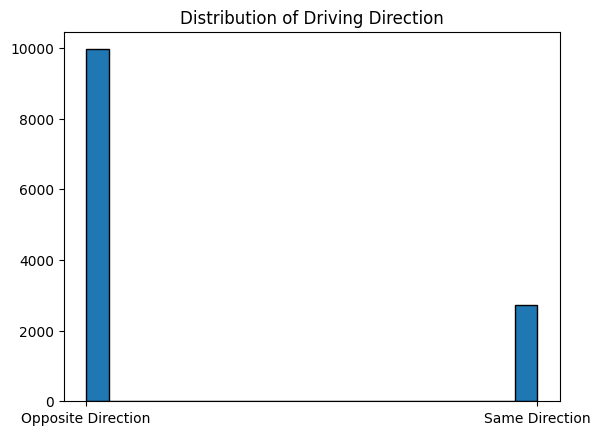

In [13]:
#graph the distribution of driving direction
plt.hist(data['direction_same'], bins=20, edgecolor='black')
plt.title('Distribution of Driving Direction')
#lable same direction or opposite direction
plt.xticks([0, 1], ['Opposite Direction', 'Same Direction'])


Text(0.5, 1.0, 'Distribution of Age by Accepted and Declined Coupons')

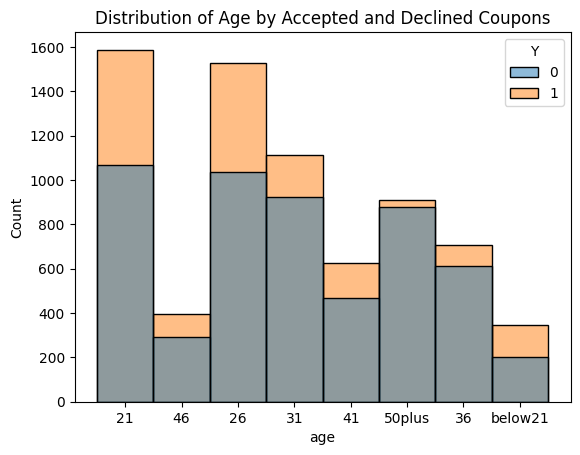

In [14]:
#graph the distribution of the age column by accepted and declined coupons
sns.histplot(data=data, x='age', hue='Y', bins=20, edgecolor='black')
plt.title('Distribution of Age by Accepted and Declined Coupons')   


([<matplotlib.axis.XTick at 0x112762b08f0>,
 [Text(0, 0, 'Opposite Direction'), Text(1, 0, 'Same Direction')])

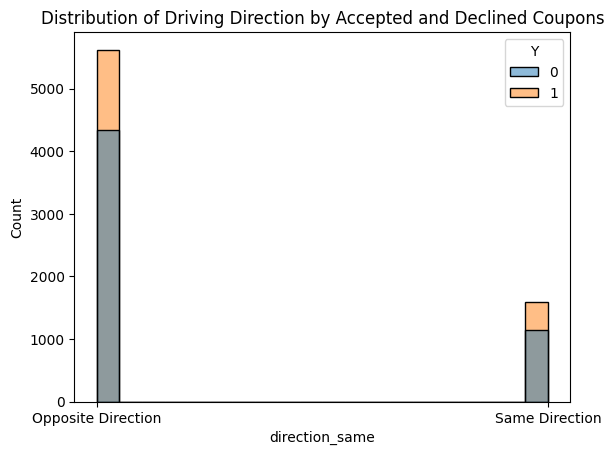

In [15]:
#graph the distribution of driving direction by accepted and declined coupons
sns.histplot(data=data, x='direction_same', hue='Y', bins=20, edgecolor='black')
plt.title('Distribution of Driving Direction by Accepted and Declined Coupons')
#lable same direction or opposite direction
plt.xticks([0, 1], ['Opposite Direction', 'Same Direction'])


**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


Text(0, 0.5, 'count')

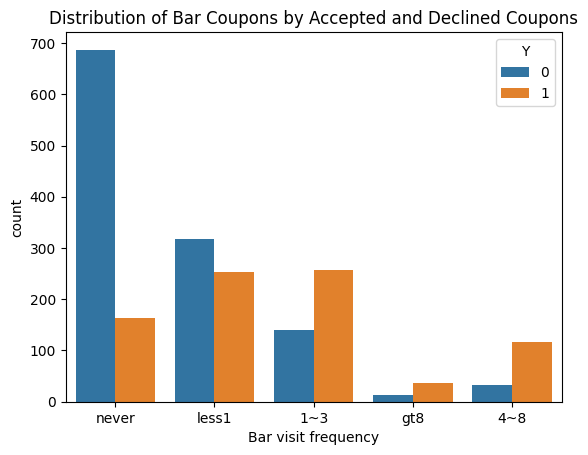

In [4]:
#create new dataframe that contains just the bar coupons
bar_coupons = data[data['coupon'] == 'Bar']
#graph the distribution of the bar coupons by accepted and declined coupons
sns.countplot(x='Bar', hue='Y', data=bar_coupons)
plt.title('Distribution of Bar Coupons by Accepted and Declined Coupons')
plt.xlabel('Bar visit frequency')
plt.ylabel('count')


2. What proportion of bar coupons were accepted?


In [11]:
#what proportion of bar coupons were accepted?
bar_accepted_count = bar_coupons[bar_coupons['Y'] == 1].shape[0]
bar_total_count = bar_coupons.shape[0]
bar_acceptance_rate = bar_accepted_count / bar_total_count
print("Bar coupons acceptance rate:", bar_acceptance_rate)


Bar coupons acceptance rate: 0.41001487357461575


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [12]:
#compare the acceptance rate between those who went to bar 3 or fewer times a month to those who went more
bar_3_or_fewer = bar_coupons[bar_coupons['Bar'].isin(['never','less1','1~3'])]
bar_more_than_3 = bar_coupons[~bar_coupons['Bar'].isin(['never','less1','1~3'])]
bar_3_or_fewer_acceptance_rate = bar_3_or_fewer[bar_3_or_fewer['Y'] == 1].shape[0] / bar_3_or_fewer.shape[0]
bar_more_than_3_acceptance_rate = bar_more_than_3[bar_more_than_3['Y'] == 1].shape[0] / bar_more_than_3.shape[0]
print("Acceptance rate for those who went to bar 3 or fewer times a month:", bar_3_or_fewer_acceptance_rate)
print("Acceptance rate for those who went to bar more than 3 times a month:", bar_more_than_3_acceptance_rate)   


Acceptance rate for those who went to bar 3 or fewer times a month: 0.37073707370737075
Acceptance rate for those who went to bar more than 3 times a month: 0.7688442211055276


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [5]:
#Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others. is there a difference?
bar_more_than_1_and_over_25 = bar_coupons[(bar_coupons['Bar'].isin(['1~3','gt8'])) & (bar_coupons['age'] > 25)]
all_others = bar_coupons[~((bar_coupons['Bar'].isin(['1~3','gt8'])) & (bar_coupons['age'] > 25))]
bar_more_than_1_and_over_25_acceptance_rate = bar_more_than_1_and_over_25[bar_more_than_1_and_over_25['Y'] == 1].shape[0] / bar_more_than_1_and_over_25.shape[0]
all_others_acceptance_rate = all_others[all_others['Y'] == 1].shape[0] / all_others.shape[0]
print("Acceptance rate for drivers who go to a bar more than once a month and are over the age of 25:", bar_more_than_1_and_over_25_acceptance_rate)
print("Acceptance rate for all others:", all_others_acceptance_rate)   


Acceptance rate for drivers who go to a bar more than once a month and are over the age of 25: 0.6624203821656051
Acceptance rate for all others: 0.3634762184380505


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [13]:
#Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had accupations other than farming, fishing, or forestry
bar_more_than_1_and_not_kid_and_not_farming = bar_coupons[(bar_coupons['Bar'].isin(['1~3','gt8'])) & (bar_coupons['passanger'] != 'Kid(s)') & (~bar_coupons['occupation'].isin(['Farming', 'Fishing', 'Forestry']))]
all_others = bar_coupons[~((bar_coupons['Bar'].isin(['1~3','gt8'])) & (bar_coupons['passanger'] != 'Kid(s)') & (~bar_coupons['occupation'].isin(['Farming', 'Fishing', 'Forestry'])))]
bar_more_than_1_and_not_kid_and_not_farming_acceptance_rate = bar_more_than_1_and_not_kid_and_not_farming[bar_more_than_1_and_not_kid_and_not_farming['Y'] == 1].shape[0] / bar_more_than_1_and_not_kid_and_not_farming.shape[0]
all_others_acceptance_rate = all_others[all_others['Y'] == 1].shape[0] / all_others.shape[0]
print("Acceptance rate for drivers who go to bars more than once a month and had passengers that were not a kid and had accupations other than farming, fishing, or forestry:", bar_more_than_1_and_not_kid_and_not_farming_acceptance_rate)
print("Acceptance rate for all others:", all_others_acceptance_rate)    


Acceptance rate for drivers who go to bars more than once a month and had passengers that were not a kid and had accupations other than farming, fishing, or forestry: 0.6862745098039216
Acceptance rate for all others: 0.33996270975761345


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [6]:
#Compare the acceptance rates between those drivers who:

#go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
#go to bars more than once a month and are under the age of 30 *OR*
#go to cheap restaurants more than 4 times a month and income is less than 50K.
drivers_condition_1 = bar_coupons[(bar_coupons['Bar'].isin(['1~3','gt8'])) & (bar_coupons['passanger'] != 'Kid(s)') & (bar_coupons['maritalStatus'] != 'Widowed')]
drivers_condition_2 = bar_coupons[(bar_coupons['Bar'].isin(['1~3','gt8'])) & (bar_coupons['age'] < 30)]
drivers_condition_3 = bar_coupons[(bar_coupons['RestaurantLessThan20'].isin(['4~8','gt8'])) & (bar_coupons['income'] < 50000)]     
drivers_condition_1_acceptance_rate = drivers_condition_1[drivers_condition_1['Y'] == 1].shape[0] / drivers_condition_1.shape[0]
drivers_condition_2_acceptance_rate = drivers_condition_2[drivers_condition_2['Y'] == 1].shape[0] / drivers_condition_2.shape[0]
drivers_condition_3_acceptance_rate = drivers_condition_3[drivers_condition_3['Y'] == 1].shape[0] / drivers_condition_3.shape[0]
print("Acceptance rate for drivers who go to bars more than once a month, had passengers that were not a kid, and were not widowed:", drivers_condition_1_acceptance_rate)
print("Acceptance rate for drivers who go to bars more than once a month and are under the age of 30:", drivers_condition_2_acceptance_rate)
print("Acceptance rate for drivers who go to cheap restaurants more than 4 times a month and income is less than 50K:", drivers_condition_3_acceptance_rate)    


Acceptance rate for drivers who go to bars more than once a month, had passengers that were not a kid, and were not widowed: 0.6862745098039216
Acceptance rate for drivers who go to bars more than once a month and are under the age of 30: 0.6869918699186992
Acceptance rate for drivers who go to cheap restaurants more than 4 times a month and income is less than 50K: 0.45348837209302323


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

In [7]:
#Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?
drivers_who_accepted_bar_coupons = bar_coupons[bar_coupons['Y'] == 1]
average_age = drivers_who_accepted_bar_coupons['age'].mean()
print("Average age of drivers who accepted bar coupons:", average_age)



Average age of drivers who accepted bar coupons: 30.73397823458283


### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [22]:
# Investigating Coffee House Coupons
coffee_coupons = data[data['coupon'] == 'Coffee House']
print("Total Coffee House coupons:", len(coffee_coupons))
print("Coupon distribution:", coffee_coupons['Y'].value_counts())

# Overall acceptance rate
coffee_accepted = coffee_coupons[coffee_coupons['Y'] == 1].shape[0]
coffee_total = coffee_coupons.shape[0]
coffee_acceptance_rate = coffee_accepted / coffee_total
print("Coffee House coupon acceptance rate:" , coffee_acceptance_rate)

Total Coffee House coupons: 3996
Coupon distribution: Y
0    2001
1    1995
Name: count, dtype: int64
Coffee House coupon acceptance rate: 0.49924924924924924


In [23]:
# Compare acceptance rate by visit frequency
coffee_never = coffee_coupons[coffee_coupons['CoffeeHouse'].isin(['never'])]
coffee_less_freq = coffee_coupons[coffee_coupons['CoffeeHouse'].isin(['less1', '1~3'])]
coffee_more_freq = coffee_coupons[coffee_coupons['CoffeeHouse'].isin(['4~8', 'gt8'])]

never_accept = coffee_never[coffee_never['Y'] == 1].shape[0] / coffee_never.shape[0] if coffee_never.shape[0] > 0 else 0
less_freq_accept = coffee_less_freq[coffee_less_freq['Y'] == 1].shape[0] / coffee_less_freq.shape[0] if coffee_less_freq.shape[0] > 0 else 0
more_freq_accept = coffee_more_freq[coffee_more_freq['Y'] == 1].shape[0] / coffee_more_freq.shape[0] if coffee_more_freq.shape[0] > 0 else 0

print("Acceptance rates by Coffee House visit frequency:")
print("Never:", never_accept)
print("Less frequent (less1, 1~3):", less_freq_accept)
print("More frequent (4~8, gt8):", more_freq_accept)

Acceptance rates by Coffee House visit frequency:
Never: 0.18878101402373246
Less frequent (less1, 1~3): 0.5600730927364094
More frequent (4~8, gt8): 0.675


In [24]:
# Analyze by age groups
young_coffee = coffee_coupons[coffee_coupons['age'] < 30]
middle_coffee = coffee_coupons[(coffee_coupons['age'] >= 30) & (coffee_coupons['age'] < 50)]
older_coffee = coffee_coupons[coffee_coupons['age'] >= 50]

young_accept = young_coffee[young_coffee['Y'] == 1].shape[0] / young_coffee.shape[0] if young_coffee.shape[0] > 0 else 0
middle_accept = middle_coffee[middle_coffee['Y'] == 1].shape[0] / middle_coffee.shape[0] if middle_coffee.shape[0] > 0 else 0
older_accept = older_coffee[older_coffee['Y'] == 1].shape[0] / older_coffee.shape[0] if older_coffee.shape[0] > 0 else 0

print("Acceptance rates by age group:")
print("Under 30: ", young_accept)
print("30-50:", middle_accept)
print(f"50+:", older_accept)


Acceptance rates by age group:
Under 30:  0.5342902711323764
30-50: 0.48471337579617835
50+: 0.42018348623853213


COFFEE HOUSE COUPON ANALYSIS - SUMMARY AND HYPOTHESIS
======================================================

Key Findings:
1. Overall acceptance rate: 0.4992 (1995/3996)
2. Visit frequency strongly impacts acceptance - regulars (67.5%) vs never visitors (18.9%)
3. Younger drivers (under 30) show higher acceptance: 0.5343


Hypothesis:
Customers most likely to accept Coffee House coupons are:
- Regular/frequent coffee house visitors (4-8+ times/month)
- Under 30 years old


This makes intuitive sense as:
- Coffee houses are primarily a morning/beverage destination
- Regular customers are intrinsically more interested in coffee deals
- The coupon is most relevant when people are in their morning routine